# Week 6 — Function 6: Bayesian Optimisation (5D)

In [1]:
# Cell 2: Imports
import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF
from scipy.stats import norm
import warnings
warnings.filterwarnings('ignore')

print('All libraries loaded successfully.')

All libraries loaded successfully.


In [2]:
# Cell 3: Load data and inspect
# Function 6: Cake recipe optimisation (5D), Maximise.
# Note: scores are negative by design — maximising means bringing the score closest to zero.

X = np.load('../data/function_6/initial_inputs.npy')
Y = np.load('../data/function_6/initial_outputs.npy')

print(f'Input  shape : {X.shape}   (n_samples x n_dimensions)')
print(f'Output shape : {Y.shape}  (n_samples,)')
print()
print('  Note: Y scores are negative by design.')
print('  Maximising = finding the recipe closest to 0 (least penalised).')
print()

# Sort descending by Y value
X_list = list(X)
Y_list = list(Y)
pairs = sorted(zip(Y_list, X_list), reverse=True)
Y_sorted = [p[0] for p in pairs]
X_sorted = [p[1] for p in pairs]

print('=' * 86)
print('  All observations (sorted descending by Y)')
print('=' * 86)
for i, (y_val, x_val) in enumerate(zip(Y_sorted, X_sorted)):
    marker = '  <-- best' if i == 0 else ''
    print(f'  [{i+1:2d}]  X = [{x_val[0]:.6f}, {x_val[1]:.6f}, {x_val[2]:.6f}, {x_val[3]:.6f}, {x_val[4]:.6f}]   Y = {y_val:+.6e}{marker}')
print('=' * 86)

best_Y = Y_sorted[0]
best_X = np.array(X_sorted[0])
print(f'\n  Best Y*  = {best_Y:.6e}')
print(f'  Best X*  = [{best_X[0]:.8f}, {best_X[1]:.8f}, {best_X[2]:.8f}, {best_X[3]:.8f}, {best_X[4]:.8f}]')

Input  shape : (20, 5)   (n_samples x n_dimensions)
Output shape : (20,)  (n_samples,)

  Note: Y scores are negative by design.
  Maximising = finding the recipe closest to 0 (least penalised).

  All observations (sorted descending by Y)
  [ 1]  X = [0.728186, 0.154693, 0.732552, 0.693997, 0.056401]   Y = -7.142649e-01  <-- best
  [ 2]  X = [0.618812, 0.331802, 0.187288, 0.756238, 0.328835]   Y = -8.292366e-01
  [ 3]  X = [0.782880, 0.536336, 0.443284, 0.859700, 0.010326]   Y = -9.357566e-01
  [ 4]  X = [0.536797, 0.308781, 0.411879, 0.388225, 0.522528]   Y = -1.144785e+00
  [ 5]  X = [0.242384, 0.844100, 0.577809, 0.679021, 0.501953]   Y = -1.209955e+00
  [ 6]  X = [0.145111, 0.896685, 0.896322, 0.726272, 0.236272]   Y = -1.233786e+00
  [ 7]  X = [0.784958, 0.910682, 0.708120, 0.959225, 0.004911]   Y = -1.247049e+00
  [ 8]  X = [0.432166, 0.715618, 0.341819, 0.705000, 0.614962]   Y = -1.294247e+00
  [ 9]  X = [0.757594, 0.355831, 0.016523, 0.434207, 0.112433]   Y = -1.309116e+00
  [

In [3]:
# Cell 4: Fit GP with StandardScaler-transformed Y
# Y is always negative by design — log(|Y|) would reverse ordering (more negative = larger |Y| = higher log).
# StandardScaler centres and scales Y, preserving the correct ordering for UCB maximisation.

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
Y_fit = scaler.fit_transform(Y.reshape(-1, 1)).ravel()
# StandardScaler used — Y is always negative by design, log(|Y|) would reverse the ordering

# Fixed RBF kernel (course style — no ConstantKernel, no optimisation)
kernel = RBF(length_scale=0.1, length_scale_bounds='fixed')
gp = GaussianProcessRegressor(kernel=kernel, alpha=1e-10)
gp.fit(X, Y_fit)

print('=' * 62)
print('  GP Fitting Results')
print('=' * 62)
print(f'  Kernel                   : {gp.kernel_}')
print(f'  Log-marginal-likelihood  : {gp.log_marginal_likelihood_value_:.4f}')
print()

# Sanity check: predict at best known point
pred_mean, pred_std = gp.predict(best_X.reshape(1, -1), return_std=True)
actual_scaled = scaler.transform([[best_Y]])[0][0]
print('  Sanity check at best known X*:')
print(f'    X*                     = [{best_X[0]:.6f}, {best_X[1]:.6f}, {best_X[2]:.6f}, {best_X[3]:.6f}, {best_X[4]:.6f}]')
print(f'    GP predicted mean      = {pred_mean[0]:.4f}  (scaled-space)')
print(f'    Actual scaled Y*       = {actual_scaled:.4f}  (scaled-space)')
print(f'    GP predicted std       = {pred_std[0]:.8f}')
print('=' * 62)

  GP Fitting Results
  Kernel                   : RBF(length_scale=0.1)
  Log-marginal-likelihood  : -28.3791

  Sanity check at best known X*:
    X*                     = [0.728186, 0.154693, 0.732552, 0.693997, 0.056401]
    GP predicted mean      = 1.7397  (scaled-space)
    Actual scaled Y*       = 1.7397  (scaled-space)
    GP predicted std       = 0.00001000


In [4]:
# Cell 5: UCB acquisition over random search (20,000 points in 5D)

np.random.seed(42)
X_grid = np.random.uniform(0, 1, size=(20000, 5))  # shape (20000, 5)

# GP predictions across the random grid
post_mean, post_std = gp.predict(X_grid, return_std=True)

# UCB acquisition: mean + beta * std
beta = 2.5  #Higher beta = more exploration at early stage (Week 1, sparse data)
acquisition = post_mean + beta * post_std  # shape (20000,)

# Next query = grid point with highest UCB
best_idx = np.argmax(acquisition)
next_x   = X_grid[best_idx]
next_acq = acquisition[best_idx]

# Portal submission string
portal_string = f'{next_x[0]:.6f}-{next_x[1]:.6f}-{next_x[2]:.6f}-{next_x[3]:.6f}-{next_x[4]:.6f}'

print('=' * 62)
print('  UCB Acquisition  (beta = 2.5, random search 20,000 pts)')
print('=' * 62)
print(f'  Grid size            : {len(X_grid)} points (random uniform, 5D)')
print(f'  Max UCB value        : {next_acq:.4f}')
print(f'  Next query point     : [{next_x[0]:.6f}, {next_x[1]:.6f}, {next_x[2]:.6f}, {next_x[3]:.6f}, {next_x[4]:.6f}]')
print()
print('  Portal submission string:')
print(f'  >>> {portal_string} <<<')
print('=' * 62)

  UCB Acquisition  (beta = 2.5, random search 20,000 pts)
  Grid size            : 20000 points (random uniform, 5D)
  Max UCB value        : 3.0445
  Next query point     : [0.705342, 0.105077, 0.763664, 0.783759, 0.051342]

  Portal submission string:
  >>> 0.705342-0.105077-0.763664-0.783759-0.051342 <<<


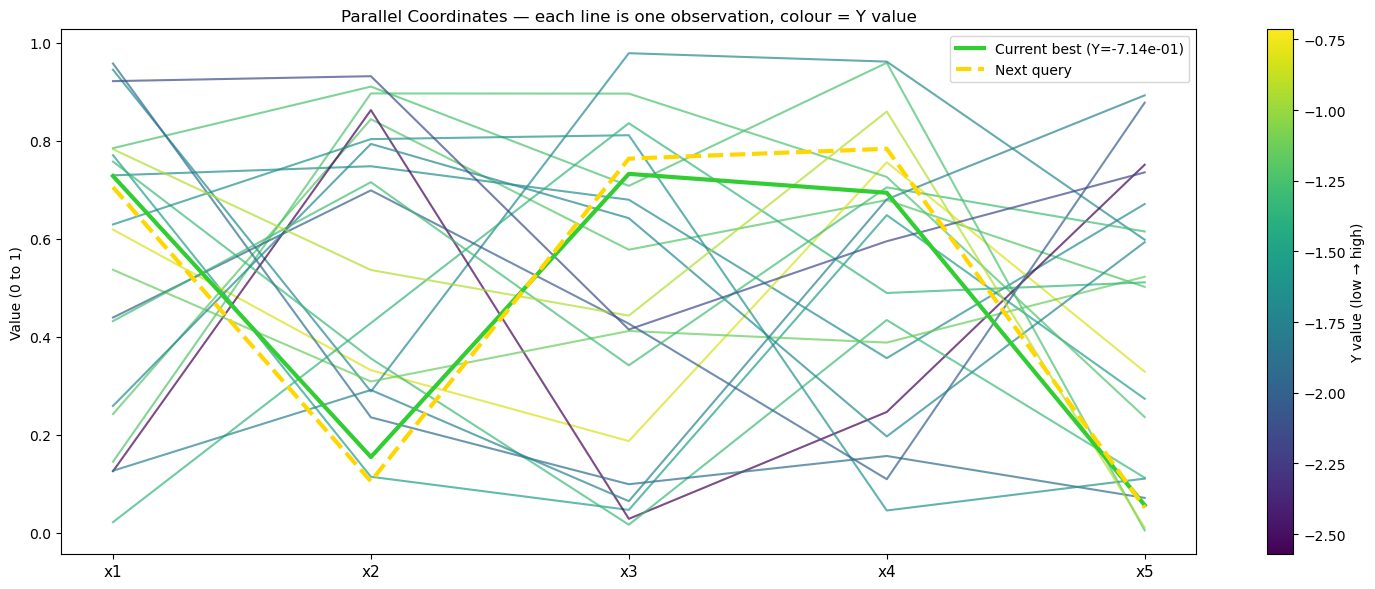

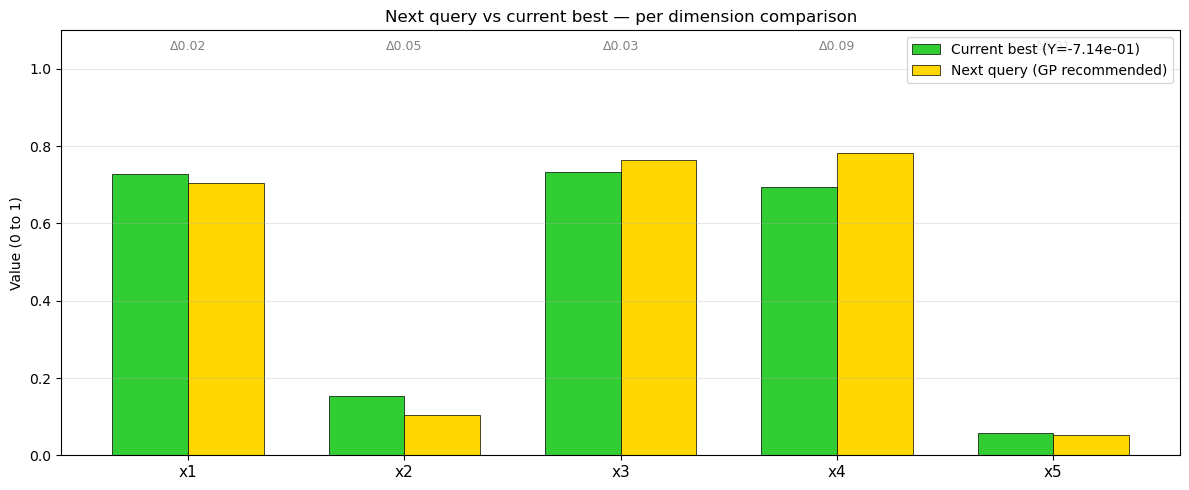

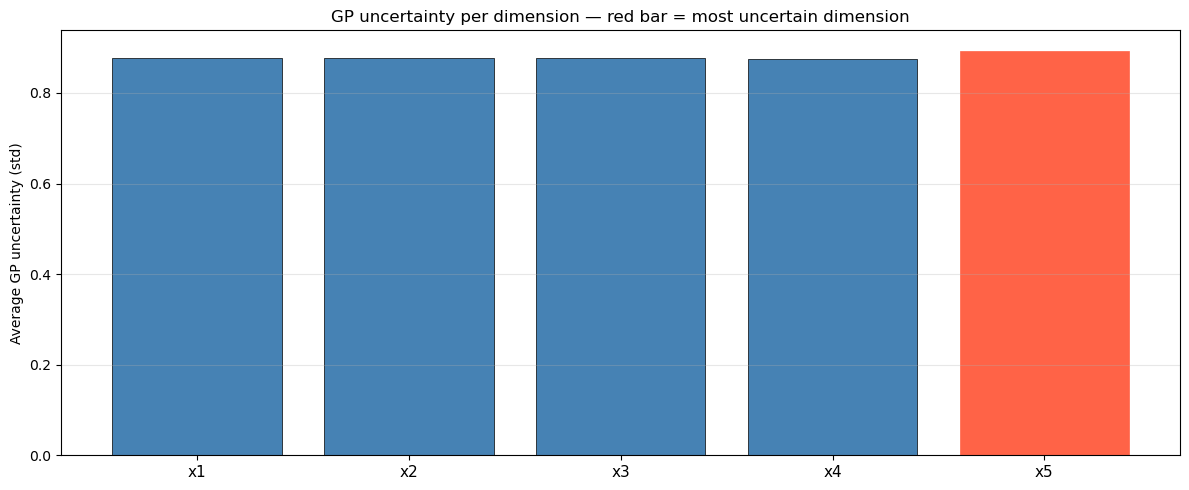

In [5]:
# Cell 6: Visualisation — three high-dimensional plots
n_dims = X.shape[1]

# ── Plot 1: Parallel Coordinates ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(15, 6))

# Normalise Y for colouring — 0=worst, 1=best
Y_norm = (Y - Y.min()) / (Y.max() - Y.min() + 1e-300)
cmap = plt.cm.viridis

# Plot each observed point as a line across all dimensions
for i in range(len(X)):
    ax.plot(range(n_dims), X[i], color=cmap(Y_norm[i]),
            alpha=0.7, linewidth=1.5)

# Plot current best as thick green line
ax.plot(range(n_dims), best_X, color='limegreen',
        linewidth=3, label=f'Current best (Y={best_Y:.2e})', zorder=5)

# Plot next query as thick gold line
ax.plot(range(n_dims), next_x, color='gold', linewidth=3,
        linestyle='--', label=f'Next query', zorder=6)

ax.set_xticks(range(n_dims))
ax.set_xticklabels([f'x{i+1}' for i in range(n_dims)], fontsize=11)
ax.set_ylabel('Value (0 to 1)')
ax.set_title('Parallel Coordinates — each line is one observation, colour = Y value')
ax.legend()
sm = plt.cm.ScalarMappable(cmap=cmap)
sm.set_array(Y)
plt.colorbar(sm, ax=ax, label='Y value (low → high)')
plt.tight_layout()
plt.show()

# ── Plot 2: Next query vs current best bar chart ──────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))

x_positions = np.arange(n_dims)
width = 0.35

ax.bar(x_positions - width/2, best_X, width,
       label=f'Current best (Y={best_Y:.2e})',
       color='limegreen', edgecolor='black', linewidth=0.5)
ax.bar(x_positions + width/2, next_x, width,
       label='Next query (GP recommended)',
       color='gold', edgecolor='black', linewidth=0.5)

ax.set_xticks(x_positions)
ax.set_xticklabels([f'x{i+1}' for i in range(n_dims)], fontsize=11)
ax.set_ylabel('Value (0 to 1)')
ax.set_ylim(0, 1.1)
ax.set_title('Next query vs current best — per dimension comparison')
ax.legend()
ax.grid(axis='y', alpha=0.3)

# Highlight dimensions where next query differs most from best
diffs = np.abs(next_x - best_X)
for i, d in enumerate(diffs):
    ax.text(i, 1.05, f'Δ{d:.2f}', ha='center', fontsize=9,
            color='red' if d > 0.2 else 'gray')

plt.tight_layout()
plt.show()

# ── Plot 3: GP uncertainty per dimension (which dims matter most) ─────────────
# Sample points varying one dimension at a time, others fixed at best_X
fig, ax = plt.subplots(figsize=(12, 5))

uncertainty_per_dim = []
x_line = np.linspace(0, 1, 50)

for dim in range(n_dims):
    X_slice = np.tile(best_X, (50, 1))  # repeat best_X 50 times
    X_slice[:, dim] = x_line            # vary only this dimension
    _, std_slice = gp.predict(X_slice, return_std=True)
    uncertainty_per_dim.append(std_slice.mean())  # average uncertainty

bars = ax.bar(range(n_dims), uncertainty_per_dim,
              color='steelblue', edgecolor='black', linewidth=0.5)

# Highlight the dimension with highest uncertainty
max_dim = np.argmax(uncertainty_per_dim)
bars[max_dim].set_color('tomato')

ax.set_xticks(range(n_dims))
ax.set_xticklabels([f'x{i+1}' for i in range(n_dims)], fontsize=11)
ax.set_ylabel('Average GP uncertainty (std)')
ax.set_title('GP uncertainty per dimension — red bar = most uncertain dimension')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [6]:
# Cell 7: Summary

print('=' * 62)
print('  SUMMARY — Bayesian Optimisation Results')
print('=' * 62)
print(f'  Function             : 5D Cake Recipe Optimisation')
print(f'  Objective            : Maximise (scores negative by design; closer to 0 = better)')
print(f'  Kernel               : RBF(length_scale=0.1, fixed)')
print(f'  Acquisition function : UCB  (beta = 2.5)')
print(f'  Y transform          : StandardScaler (Y always negative)')
print(f'  Grid search          : Random uniform (20,000 points, 5D)')
print()
print(f'  Current best X*      : [{best_X[0]:.6f}, {best_X[1]:.6f}, {best_X[2]:.6f}, {best_X[3]:.6f}, {best_X[4]:.6f}]')
print(f'  Current best Y*      : {best_Y:.6e}')
print()
print(f'  Next query point     : [{next_x[0]:.6f}, {next_x[1]:.6f}, {next_x[2]:.6f}, {next_x[3]:.6f}, {next_x[4]:.6f}]')
print()
print('  Portal submission string:')
print(f'  >>> {portal_string} <<<')
print('=' * 62)

  SUMMARY — Bayesian Optimisation Results
  Function             : 5D Cake Recipe Optimisation
  Objective            : Maximise (scores negative by design; closer to 0 = better)
  Kernel               : RBF(length_scale=0.1, fixed)
  Acquisition function : UCB  (beta = 2.5)
  Y transform          : StandardScaler (Y always negative)
  Grid search          : Random uniform (20,000 points, 5D)

  Current best X*      : [0.728186, 0.154693, 0.732552, 0.693997, 0.056401]
  Current best Y*      : -7.142649e-01

  Next query point     : [0.705342, 0.105077, 0.763664, 0.783759, 0.051342]

  Portal submission string:
  >>> 0.705342-0.105077-0.763664-0.783759-0.051342 <<<
